<a href="https://colab.research.google.com/github/JorgeEncinas/pytorch_ztm/blob/main/01_workflow_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### The Process

1. Get data ready (turn into tensors)
2. Build or pick a pretrained model (to suit your problem)
  - Pick a Loss Function & Optimizer
  - Build a Training Loop
3. Fit the model to the data and make a prediction
4. Evaluate the model
5. Improve through Experimentation
6. Save and reload your trained model

## End-to-End Example
We will see an E2E Example

In [1]:
topics = {
    1: "Data: Prepare and Load",
    2: "Build the Model",
    3: "Fit the Model (Training)",
    4: "Naking Predictions and Evaluating the Model (Inference)",
    5: "Saving and Loading a Model",
    6: "Putting it all together"
}

In [2]:
import torch
from torch import nn # Contains all of PyTorch's building blocks for Neural Networks
import matplotlib.pyplot as plt

In [3]:
torch.__version__

'2.6.0+cu124'

### 1. Data - Preparing and Loading

Data can be almost anything... in Machine Learning

- Excel Spreadsheet
- Images of any kind
- Videos (Youtube has lots of data)
- Audio like songs or podcasts
- DNA
- Text

## Machine Learning - A Game of 2 Parts

1. Get data into numerical representations
2. Build a model to learn patterns in that numerical representation

## Let's get started
Let's create *known* data using the Linear Regression formula

## Linear Regression
Y = a + bX

* b - slope or gradient
* a - intercept
* X - explanatory variable

We'll use this formula to create a straight-ish line with *known* parameters

In [4]:
# The TRUE model
weight = 0.7 # The model weights or parameters
bias = 0.3   # The intercept

In [5]:
# Now let's create data for plotting
start = 0
end = 1
step = 0.02
X = torch.arange(
    start=start,
    end=end,
    step=step
)
X.shape, X.ndim, X

(torch.Size([50]),
 1,
 tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800, 0.1000, 0.1200, 0.1400, 0.1600,
         0.1800, 0.2000, 0.2200, 0.2400, 0.2600, 0.2800, 0.3000, 0.3200, 0.3400,
         0.3600, 0.3800, 0.4000, 0.4200, 0.4400, 0.4600, 0.4800, 0.5000, 0.5200,
         0.5400, 0.5600, 0.5800, 0.6000, 0.6200, 0.6400, 0.6600, 0.6800, 0.7000,
         0.7200, 0.7400, 0.7600, 0.7800, 0.8000, 0.8200, 0.8400, 0.8600, 0.8800,
         0.9000, 0.9200, 0.9400, 0.9600, 0.9800]))

We don't want it as a rank-0 vector, but as a column vector.

In [6]:
X = X.unsqueeze(
    dim=1 # 0 means 'along the column dimension', so we end up with a shape (1, 50) and ndim 2.
)

In [7]:
X.shape, X.ndim, X

(torch.Size([50, 1]),
 2,
 tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800],
         [0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]))

So we can see that the dim=1 gave us our desired result. We need to compute. for each of these increments in the X axis, the expected outcome or GROUND TRUTH (y)

In [8]:
y = weight * X + bias # As you can imagine, this is applied element-wise.
# Thus, this line multiplied the weights by all the values generated at each step, and then added the bias
# No randomness yet.

In [9]:
y.shape, y.ndim, y

(torch.Size([50, 1]),
 2,
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [0.4680],
         [0.4820],
         [0.4960],
         [0.5100],
         [0.5240],
         [0.5380],
         [0.5520],
         [0.5660],
         [0.5800],
         [0.5940],
         [0.6080],
         [0.6220],
         [0.6360],
         [0.6500],
         [0.6640],
         [0.6780],
         [0.6920],
         [0.7060],
         [0.7200],
         [0.7340],
         [0.7480],
         [0.7620],
         [0.7760],
         [0.7900],
         [0.8040],
         [0.8180],
         [0.8320],
         [0.8460],
         [0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [10]:
X[:10 :], y[:10, :], len(X) #or you can just do X[:10], y[:10], which implies the selection of the entire other dimensions I guess

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50)

### Splitting data into 3 datasets
Training, Validation and Test sets.

Simply put...
- Training Set: Your model learns patterns from this one
- Validation Set: An evaluation so that you may tune your model
- Test Set: a final evaluation to see if your model actually does generalize well. Do not use until the very end. You cannot tune using this one.

## The percentage split

* Training Set - ~60-80%
* Validation Set - ~10-20%
* Test Set - ~10-20%

Sometimes you don't have enough data for the Validation Set, it says here (So no Tuning using the Validation Set in those cases, I guess).

In [11]:
len(X), len(y)

(50, 50)

Let's split the data now...

In [12]:
# Create a Train/Test split
train_split = int(0.8 * len(X)) #Let's get 80%
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

Note we did not shuffle it; perhaps we should've done that.

In [13]:
torch.manual_seed(seed=10)
randomized_indices = torch.randperm(n=50) #randperm returns from 0 to n-1

randomized_indices.shape, randomized_indices

(torch.Size([50]),
 tensor([37, 36, 38,  2, 22, 25, 21, 32, 33, 10, 26, 40, 23,  3,  4,  8, 44, 43,
          9, 29, 48, 45, 34, 46, 35, 14, 11, 18, 24, 16, 19,  0, 12,  6, 20, 30,
         49,  7, 47, 41, 13, 42, 17,  5,  1, 31, 39, 27, 15, 28]))

In [14]:
X_randomized = X[randomized_indices]

X.shape, X_randomized.shape, X[:5], X_randomized[:5]

(torch.Size([50, 1]),
 torch.Size([50, 1]),
 tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.7400],
         [0.7200],
         [0.7600],
         [0.0400],
         [0.4400]]))

In [15]:
y_randomized = y[randomized_indices]

y.shape, y_randomized.shape, y[:5], y_randomized[:5]

(torch.Size([50, 1]),
 torch.Size([50, 1]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]),
 tensor([[0.8180],
         [0.8040],
         [0.8320],
         [0.3280],
         [0.6080]]))

In [16]:
trainr_split = int(0.8 * len(X_randomized)) # X and X_randomized are the same length btw, but I am keeping it consistent
X_trainr = X_randomized[:trainr_split]
y_trainr = y_randomized[:trainr_split]
X_testr = X_randomized[trainr_split:]
y_testr = y_randomized[trainr_split:]

X_trainr.shape, y_trainr.shape, X_testr.shape, y_testr.shape

(torch.Size([40, 1]),
 torch.Size([40, 1]),
 torch.Size([10, 1]),
 torch.Size([10, 1]))

## Visualizing our data
Let's use matplot (imported pyplot as plt) to graph or visualize our data.

Data explorer's motto: visualize, visualize, visualize

In [17]:
def plot_predictions(
    train_data = X_train,
    train_labels=y_train,
    test_data=X_test,
    test_labels=y_test,
    predictions=None
):
  plt.figure(
      figsize=(10,7)
  )
  plt.scatter(
      x=train_data,
      y=train_labels,
      c="b", # Color 'b' as in 'blue'. There is 'g', 'r', 'c' (cyan), 'm' (magenta), 'y' (yellow), 'k' (black), 'w' (white), but there are other ways to write it.
      s=4, # Marker size in points
      label="Training Data" # Label displayed in the legend
  )
  plt.scatter(
      x=test_data,
      y=test_labels,
      c="g",
      s=4,
      label="Test Data"
  )

  if predictions is not None:
    plt.scatter(
        x=test_data,
        y=predictions,
        c="r",
        s=4,
        label="Model Predictions"
    )

  plt.legend( #Places a legend on the axes.
      prop={ "size":14 } #Font properties of the legend (FontProperties)
  )

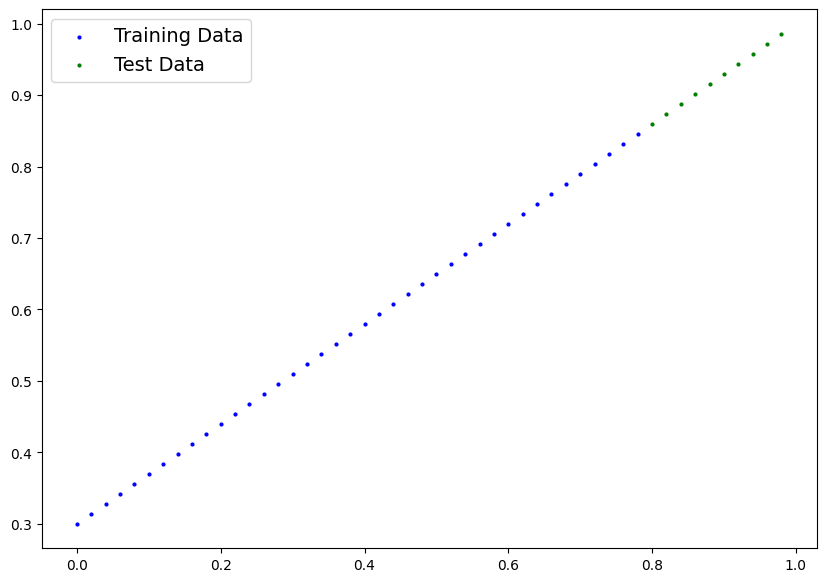

In [18]:
plot_predictions()

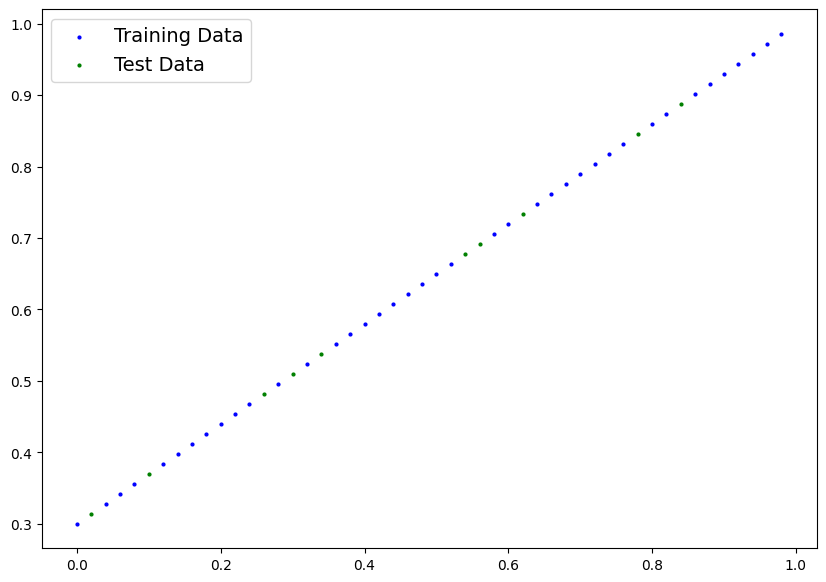

In [19]:
plot_predictions(
    train_data=X_trainr,
    train_labels=y_trainr,
    test_data=X_testr,
    test_labels=y_testr
)

See how the points are now shuffled here? Pretty cool! However, it might be the case that we're interested in having them all at the end for now, for visualization purposes (i.e. seeing the red dots slowly approximate the actual function as the iterations go on).

## 2. Building a Linear Regression Model

A model with a parameter for 'a' (intercept) and a parameter for 'b' (weights)

In [20]:
#Linear Regression model class
class LinearRegressionModel(nn.Module): #Almost everything in PyTorch inherits from nn.Module. It's like an essential building block. "Your models should also subclass this class"
  #Modules can also contain other modules, so you can stack them on top of each other, building more complex objects.
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter( #nn.parameter is "A kind of tensor that is to be considered a Module Parameter".
      data=torch.randn(
          size=(1, ),
          requires_grad=True,
          dtype=torch.float
      ),
      requires_grad=True #The video actually doesnt set this one. It is True by default too.
    )
    self.bias = nn.Parameter(
        data=torch.randn(
            size=(1, ), #size, a sequence of integers defining the shape of the output tensor. This model is very simple, just one weight, just one bias term.
            requires_grad=True,
            dtype=torch.float
        ),
        requires_grad=True
    )

  def forward(self, x : torch.Tensor) -> torch.Tensor:
    return self.weights*x + self.bias #In essence a calculation. Note our numbers will be applied element-wise

We will initialize the weights to random values, and the model must adjust them so that the function approximates the training labels using the training data.

This is done through two main algorithms
1. Gradient Descent
2. Backpropagation

PyTorch has already implemented Gradient Descent and Backpropagation for us, luckily.

## Our class

- nn.Module (contains all building blocks for neural networks)
- init constructor: We initialize Model Parameters
  - This can be different layers from torch.nn, single parameters, hard-coded values or functions
- requires_grad (set to True) means PyTorch keeps track of operations applied to the tensor to set prepare for when you calculate gradients (and later apply them to adjust the weights tensor).
- Forward Pass: any subclass of nn.Module NEEDS to OVERRIDE forward(). This defines the forward computation of the model.


## PyTorch Model Building Eseentials

* torch.nn - contains all of the building blocks for computational graphs (a NN can be considered a computational graph)
* torch.nn.Parameter
  - What parameters should our model try and learn?
  - Often a PyTorch layer from torch.nn will set these for us.
* torch.nn.Module
  - The base class for all NN Modules. If you subclass it, you should overwrite forward()
* torch.optim
  - This is where the optimizers in PyTorch live. They help with Gradient Descent
  - The adjustment of parameters. Optimizer contains the algorithm to perform said adjustment.
  - We tell the model parameters in nn.Parameter how to BEST change, so that we improve Gradient Descent and reduce the Loss.
* def forward()
  - All nn.Module subclasses require you to overwrite forward()
  - This method defines what happens in the forward computation.

## Steps and corresponding modules

1. Getting data ready (into tensors)
  - torchvision.transforms
  - torch.utils.data.Dataset
  - torch.utils.data.DataLoader
2. Build or pick a pretrained model (to suit the problem)
  - Picking a Loss Function
    - torch.nn
    - torch.nn.Module
    - torchvision.models (Pretrained models for vision)
  - Picking an Optimizer
    - torch.optim
3. Fit the model to the data and make a prediction
4. Evaluate the model
  - torchmetrics
5. Improve through experimentation
  - torch.utils.tensorboard
6. Save and reaload your trained model

### Checking the contents of our PyTorch Model

We created a class, a template to initialize a model. Now let's create an instance of it

In [21]:
model = LinearRegressionModel()
print(model.parameters())
print("-----------------")
list(model.parameters())

<generator object Module.parameters at 0x7fc9ea591000>
-----------------


[Parameter containing:
 tensor([0.8084], requires_grad=True),
 Parameter containing:
 tensor([-1.8224], requires_grad=True)]

As you can see, our model started with randomized parameters. And if you run it again and again the values are different each time (yes, randomized).


In [22]:
# Another way you can see the parameters clearly. Even better, since it's clear what the weights and bias are.
model.state_dict()

OrderedDict([('weights', tensor([0.8084])), ('bias', tensor([-1.8224]))])

In [23]:
# Our model's goal.
weight, bias

(0.7, 0.3)

Gradient Descent and Backpropagation will move our model's values to be as close as possible to the actual values

### Making predictions (before training) with torch.inference_mode()

To check our model's predictive power, let's see how well it predicts before training.

In [24]:
# Make predictions with model
with torch.inference_mode(): #Inference mode is the right way of using it. Makes inference run faster.
  y_preds = model(X_test)

#Alternative. Similar.
with torch.no_grad(): #However inference_mode is the preferred way over this one.
  y_preds2 = model(X_test)

y_preds

tensor([[-1.1757],
        [-1.1595],
        [-1.1434],
        [-1.1272],
        [-1.1110],
        [-1.0949],
        [-1.0787],
        [-1.0625],
        [-1.0464],
        [-1.0302]])

In [25]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

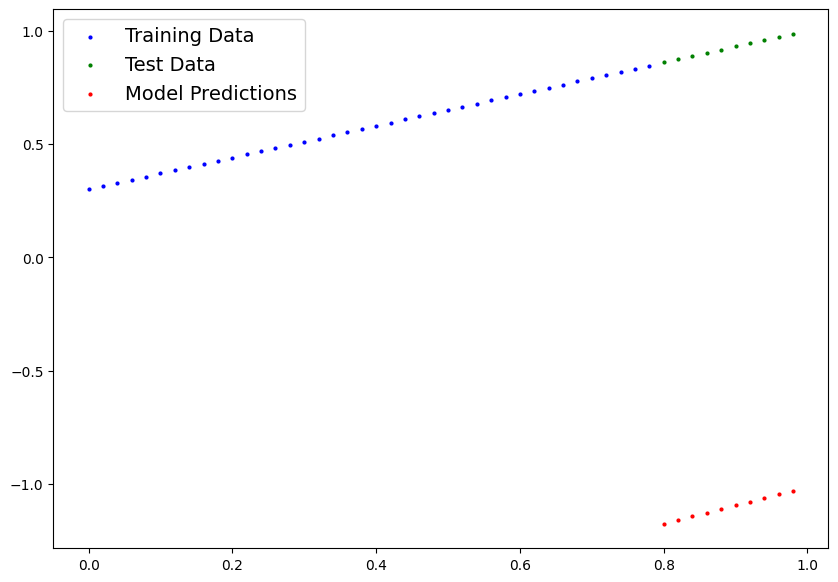

In [26]:
plot_predictions(predictions=y_preds)

With randomized parameters, our model essentially makes random predictions, since it has not learned anything yet.

## 3. Training a Model

We move the model from some unknown parameters to some known parameters.

From a poor representation, to a better representation of the data. Our representation thus far is poor, given that our predictions are way off.

## Measuring how poor or how good our model's predictions are (so we can adjust it): LOSS FUNCTION

Cost Function - Loss Function - Criterion
Depending on where you see it, it may be referring to the same thing.

* **Loss Function:** A function to measure how wrong your model's predictions are to the ideal outputs. Lower is better.
* **Optimizer:** Takes into account the loss of a model and adjusts the model's parameters (e.g. weight and bias) to improve the loss function

For PyTorch, we need
- A Training Loop
- A Testing Loop

In [27]:
list(model.parameters())

[Parameter containing:
 tensor([0.8084], requires_grad=True),
 Parameter containing:
 tensor([-1.8224], requires_grad=True)]

In [28]:
model.state_dict()

OrderedDict([('weights', tensor([0.8084])), ('bias', tensor([-1.8224]))])

### Optimizer and Loss Function
Let's work on setting up an Optimizer and Loss Function
The Optimization Loop (training loop) nudges the parameter values towards values that lower the loss function.

Lowering the loss will mean that your parameters will be closer (by that evaluation metric) to the true function.

## Loss Functions in PyTorch
torch.nn has many loss functions
- CrossEntropyLoss
- L1Loss (which is the Mean Absolute Error)
- MSELoss (L2 Loss, Mean Square Error)
- among many, many other options, which may be problem-specific

## L1 Loss
"Creates a criterion that measures the MAE btw each element in the input x and target y"

It's the average of the absolute differences between each target and our prediction for that target.

- X: 5
- y: 3
- y_hat: 2

The absolute difference is |y - y_hat|

We want to minimize that difference, making our predictions closer to the real value!

## Optimizer
Often picking a loss function and an optimizer come as part of the same package; they work in tandem (but perhaps not always).

- torch.optim is where the optimizers are.

If we go to the page in the documentation, we see that torch.optim is a package implementing optimization algorithms. "Most commonly used methods are already supported, and the interface is general enough, so that more sophisticated ones can also be easily integrated in the future". some optimizer Algorithms:

- Adam
- AdamW
- RMSprop
- SGD (Stochastic Gradient Descent) - popular (though some are improvements on top of it)

If you remember, improvement is a two-step process
- Gradient Descent -> Stochastic Gradient Descent (for example)
- Backpropagation



In [29]:
loss_fn = nn.L1Loss() #MAE

optimizer = torch.optim.SGD(
  params=model.parameters(),
  lr=0.01 #Learning Rate (The step size for each iteration of adjustment of the parameters)
)

In an optimizer, often you will need to set
- params: the model parameters you'd like to optimize
- lr (learning rate): hyperparameter to define how big/small the optimizer changes the parameters with each step (small lr - small steps and vice versa).

Q: Loss / Optimizer pair?
A: Problem specific. You can get an idea with experience
  - Regression: MAE and SGD may suffice, for example.
  - Classification Dog/Cat photo: BCELoss (Binary Cross Entropy Loss), for another example.

## Building a Training Loop (and a Testing Loop) in PyTorch

A couple of things we need in a Training Loop:
0. Loop through the data
1. Forward pass (this involves data moving through our model's forward() functions)
  - also called Forward Propagation
2. Calculate the Loss (compare forward pass Predictions to Ground Truth Labels)
3. Optimizer Zero Grad
4. Loss Backward (**Backpropagation**)
  - Move Backwards through the network to calculate the Gradients of each of the parameters of our model with respect to the Loss
5. Optimizer Step (**Gradient Descent**)
  - Use the Optimizer to adjust our model's parameters to try and improve the loss

Gradient is the slope. We want to move towards our gradient being nothing (downwards).

In [30]:
# An epoch is one loop through the data.
epochs = 10000

# Track Experiments
epoch_count = []
loss_values = []
test_loss_values = []

# 0. Loop through the data
for epoch in range(epochs):
  # Set the model to training mode (which is the default)
  model.train() #Train mode in PyTorch sets all parameters require_grad=True

  # 1. Forward Pass
  y_pred = model(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad() #Zeroing the gradients so that we don't accidentally re-apply the same changes again and again.

  # 4. Perform Backpropagation on the Loss w.r.t. the parameters of the model
  loss.backward()

  # 5. Step the optimizer (perform Gradient Descent)
  optimizer.step() # By default how the optimizer changes will accumulate them through the loop

  ### Testing
  model.eval() #Turns off settings not needed for evaluation
  if epoch % 100 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss.item())
    with torch.inference_mode():
      y_test_preds = model(X_test)
      test_loss = loss_fn(y_test_preds, y_test)
    test_loss_values.append(test_loss.item())
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")
    print(model.state_dict())
    print("------------------")


Epoch: 0 | Loss: 2.080146312713623 | Test Loss: 2.012470245361328
OrderedDict([('weights', tensor([0.8123])), ('bias', tensor([-1.8124]))])
------------------
Epoch: 100 | Loss: 0.9280465841293335 | Test Loss: 0.6653691530227661
OrderedDict([('weights', tensor([1.2023])), ('bias', tensor([-0.8124]))])
------------------
Epoch: 200 | Loss: 0.1540037989616394 | Test Loss: 0.30570846796035767
OrderedDict([('weights', tensor([1.4350])), ('bias', tensor([-0.0484]))])
------------------
Epoch: 300 | Loss: 0.11665666103363037 | Test Loss: 0.272102415561676
OrderedDict([('weights', tensor([1.2787])), ('bias', tensor([0.0571]))])
------------------
Epoch: 400 | Loss: 0.08230972290039062 | Test Loss: 0.19144168496131897
OrderedDict([('weights', tensor([1.1077])), ('bias', tensor([0.1286]))])
------------------
Epoch: 500 | Loss: 0.047972265630960464 | Test Loss: 0.11146628856658936
OrderedDict([('weights', tensor([0.9370])), ('bias', tensor([0.2006]))])
------------------
Epoch: 600 | Loss: 0.01

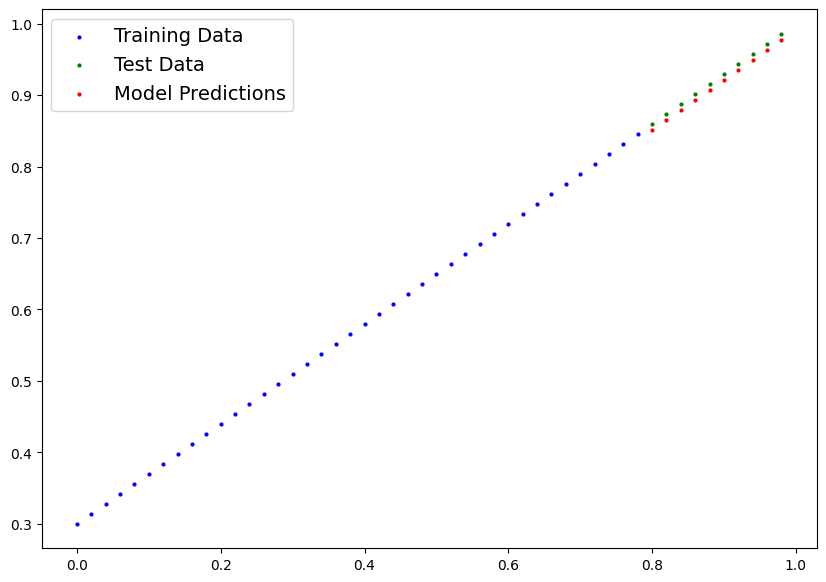

In [31]:
plot_predictions(predictions=y_test_preds)

In [32]:
model.state_dict()

OrderedDict([('weights', tensor([0.7042])), ('bias', tensor([0.3016]))])

In [33]:
weight, bias

(0.7, 0.3)

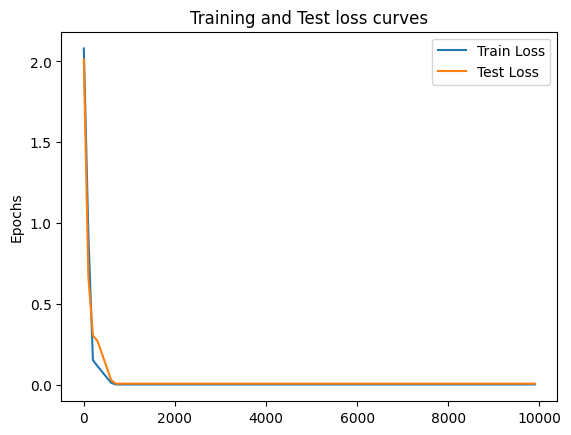

In [34]:
plt.plot(epoch_count, loss_values, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.title("Training and Test loss curves")
plt.ylabel("Epochs")
plt.legend()

## Saving a Model in PyTorch (for later reuse)

There are 3 main ways ti save and load models in PyTorch

1. torch.save() - allows you to save a PyTorch object in Python's 'pickle' format
2. torch.load() - allows you to load a saved PyTorch object
3. torch.nn.Module.load_state_dict() - allows you to load a model's saved state dictionary.

In [35]:
model.state_dict()

OrderedDict([('weights', tensor([0.7042])), ('bias', tensor([0.3016]))])

### Saving your model
They recommend saving the State Dictionary over saving the Entire Model

[Saving and Loading in PyTorch](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html)

In [36]:
from pathlib import Path

# 1. Create the Model Directory
MODELS_PATH = Path("models")
MODELS_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create the Model Save Path by adding the model name
MODEL_NAME = "01_workflow_video_model.pth"
MODELS_SAVE_PATH = MODELS_PATH / MODEL_NAME

In [37]:
# 3. Call for saving your model
print(f"Saving model to: {MODELS_SAVE_PATH}")
torch.save(model.state_dict(), MODELS_SAVE_PATH)

Saving model to: models/01_workflow_video_model.pth


You can set it up to be saved into your Google Drive, so that you can retrieve it later.

## Loading your model

We save the model's state_dict() and load it using a built-in load_state_dict()

In [38]:
model_2 = LinearRegressionModel()

loaded_params = torch.load(
  MODELS_SAVE_PATH,
  weights_only=True
)
model_2.load_state_dict(loaded_params)

model_2.eval() #Set to inference mode, since usually you load your model ready to be used!

LinearRegressionModel()

In [39]:
model_2.state_dict(), model.state_dict()

(OrderedDict([('weights', tensor([0.7042])), ('bias', tensor([0.3016]))]),
 OrderedDict([('weights', tensor([0.7042])), ('bias', tensor([0.3016]))]))

### Making predictions with our loaded model

In [40]:
model_2.eval()
with torch.inference_mode():
  loaded_model_preds = model_2(X_test)
  y_test_preds = model(X_test)

loaded_model_preds, y_test_preds

(tensor([[0.8650],
         [0.8790],
         [0.8931],
         [0.9072],
         [0.9213],
         [0.9354],
         [0.9495],
         [0.9635],
         [0.9776],
         [0.9917]]),
 tensor([[0.8650],
         [0.8790],
         [0.8931],
         [0.9072],
         [0.9213],
         [0.9354],
         [0.9495],
         [0.9635],
         [0.9776],
         [0.9917]]))

## Putting it all together now.

Let's try doing all that again to recap, memorize, and practice

In [41]:
# 0 Import stuff
import torch
from torch import nn
import matplotlib.pyplot as plt

In [42]:
# 1. Create the Data

weight = 9
bias = -2

X_2 = torch.arange(start=1, end = 101, step=1)
y_2 = X_2*weight + bias

Text(0.5, 1.0, 'Synthetic Data')

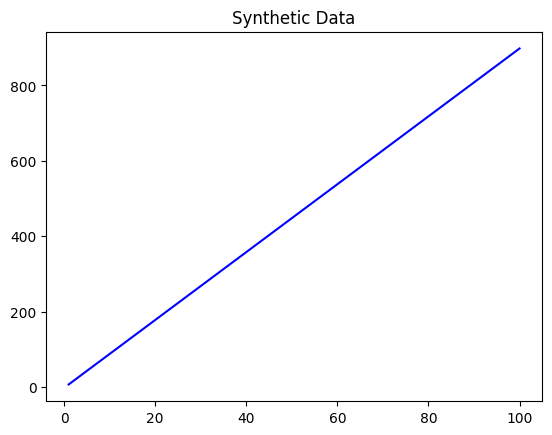

In [43]:
plt.plot(X_2, y_2, c="b")
plt.title("Synthetic Data")

In [44]:
# Split the data into train and test
train_portion_2 = int(len(X_2) * 0.8)
print(train_portion_2)
X_train_2 = torch.tensor(X_2[:train_portion_2], dtype=torch.float32)
y_train_2 = torch.tensor(y_2[:train_portion_2], dtype=torch.float32)

X_test_2 = torch.tensor(X_2[train_portion_2:], dtype=torch.float32)
y_test_2 = torch.tensor(y_2[train_portion_2:], dtype=torch.float32)

len(X_train_2), len(y_train_2), len(X_test_2), len(y_test_2)

80


<ipython-input-44-3041439404>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_2 = torch.tensor(X_2[:train_portion_2], dtype=torch.float32)
<ipython-input-44-3041439404>:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_2 = torch.tensor(y_2[:train_portion_2], dtype=torch.float32)
<ipython-input-44-3041439404>:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_2 = torch.tensor(X_2[train_portion_2:], dtype=torch.float32)
<ipython-input-44-3041439404>:8: UserWarning: To copy construct from a tensor, it is recommended to u

(80, 80, 20, 20)

In [45]:
X_train_2, y_train_2, X_test_2, y_test_2

(tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14.,
         15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27., 28.,
         29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39., 40., 41., 42.,
         43., 44., 45., 46., 47., 48., 49., 50., 51., 52., 53., 54., 55., 56.,
         57., 58., 59., 60., 61., 62., 63., 64., 65., 66., 67., 68., 69., 70.,
         71., 72., 73., 74., 75., 76., 77., 78., 79., 80.]),
 tensor([  7.,  16.,  25.,  34.,  43.,  52.,  61.,  70.,  79.,  88.,  97., 106.,
         115., 124., 133., 142., 151., 160., 169., 178., 187., 196., 205., 214.,
         223., 232., 241., 250., 259., 268., 277., 286., 295., 304., 313., 322.,
         331., 340., 349., 358., 367., 376., 385., 394., 403., 412., 421., 430.,
         439., 448., 457., 466., 475., 484., 493., 502., 511., 520., 529., 538.,
         547., 556., 565., 574., 583., 592., 601., 610., 619., 628., 637., 646.,
         655., 664., 673., 682., 691., 700., 709., 718.]),

In [46]:
# Define your model: Parameters and Forward Pass
class LRModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight = nn.Parameter(
        data=torch.randn((1, ), dtype=torch.float32, requires_grad=True),
        requires_grad=True
      )
    self.bias = nn.Parameter(
        data=torch.randn((1, ), dtype=torch.float32, requires_grad=True),
        requires_grad=True
      )

  def forward(self, x):
    return x*self.weight + self.bias

In [47]:
# Initialize the model
model_LR = LRModel()

# Initialize your loss function
loss_LR = torch.nn.L1Loss()

# Initialize your optimizer
optim_LR = torch.optim.SGD(params=model_LR.parameters(), lr=0.01)

In [48]:
# Now for the training loop

epochs_LR = 50000

loss_LR_array = []
test_loss_LR_array = []
epochs_LR_count = []

for epoch in range(epochs_LR):

  # Set to training mode
  model_LR.train()

  # Calculate Predictions
  y_train_LR_preds = model_LR.forward(X_train_2)

  # Calculate the loss based on predictions
  loss_calculated_LR = loss_LR(y_train_LR_preds, y_train_2)

  # Reset optimizer grads just in case
  optim_LR.zero_grad()

  # Calculate gradients using the loss
  loss_calculated_LR.backward()

  # Apply gradients
  optim_LR.step()

  if epoch % 1000 == 0:
    epochs_LR_count.append(epoch)
    loss_LR_array.append(loss_calculated_LR.item())


    model.eval()
    with torch.inference_mode():
      y_test_LR_preds = model_LR.forward(X_test_2)
      test_loss_LR = loss_LR(y_test_LR_preds, y_test_2)

    test_loss_LR_array.append(test_loss_LR.item())

    print(f"Epoch: {epoch} | Loss: {loss_calculated_LR} | Test Loss: {test_loss_LR}")
    print("____________________________")



Epoch: 0 | Loss: 411.53924560546875 | Test Loss: 884.3836669921875
____________________________
Epoch: 1000 | Loss: 2.4884800910949707 | Test Loss: 32.42781448364258
____________________________
Epoch: 2000 | Loss: 2.1603946685791016 | Test Loss: 32.858177185058594
____________________________
Epoch: 3000 | Loss: 0.6796035766601562 | Test Loss: 35.99738311767578
____________________________
Epoch: 4000 | Loss: 1.1160283088684082 | Test Loss: 34.8700065612793
____________________________
Epoch: 5000 | Loss: 0.7826167345046997 | Test Loss: 35.46256637573242
____________________________
Epoch: 6000 | Loss: 0.3796122968196869 | Test Loss: 36.32727813720703
____________________________
Epoch: 7000 | Loss: 0.3796122968196869 | Test Loss: 36.32727813720703
____________________________
Epoch: 8000 | Loss: 0.3796122968196869 | Test Loss: 36.32727813720703
____________________________
Epoch: 9000 | Loss: 0.3796122968196869 | Test Loss: 36.32727813720703
____________________________
Epoch: 10000 

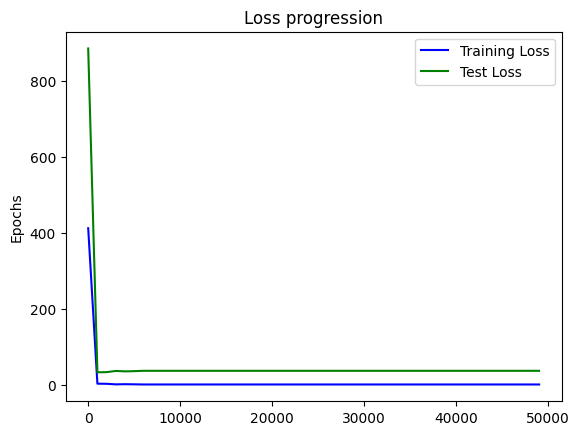

In [49]:
plt.plot(epochs_LR_count, loss_LR_array, c="b", label="Training Loss")
plt.plot(epochs_LR_count, test_loss_LR_array, c="g", label="Test Loss")
plt.title("Loss progression")
plt.ylabel("Epochs")
plt.legend()

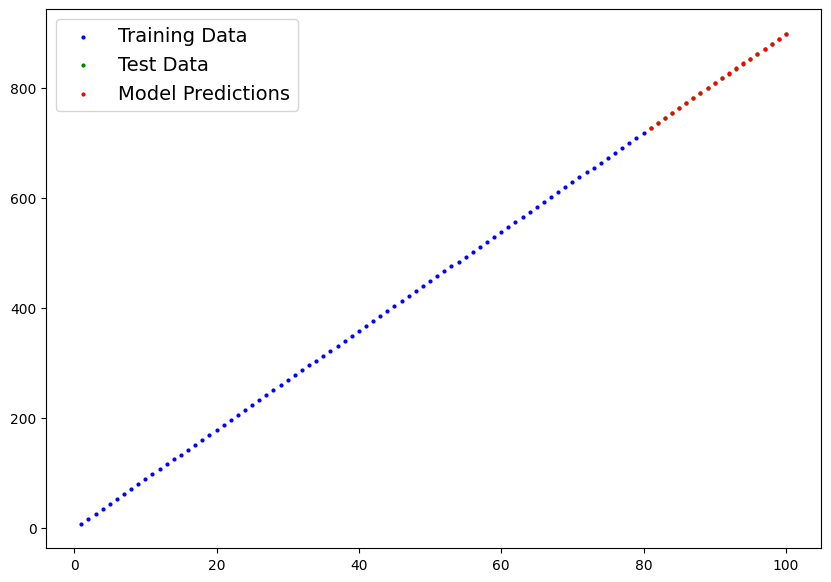

In [50]:
model_LR.eval()
with torch.inference_mode():
  y_test_LR_preds = model_LR.forward(X_test_2)
plot_predictions(
    train_data = X_train_2,
    train_labels=y_train_2,
    test_data=X_test_2,
    test_labels=y_test_2,
    predictions=y_test_LR_preds
  )

In [51]:
# Save the model (this one is easier to look up each time, seems like a very specific thing to memorize)
from pathlib import Path

MODELS_PATH = Path("models")
MODELS_PATH.mkdir(parents=True, exist_ok=True)
MODEL_LR_FILENAME = "01_workflow_video_LR_recreation.pth"

MODEL_LR_SAVE_PATH = MODELS_PATH / MODEL_LR_FILENAME

MODEL_LR_SAVE_PATH

PosixPath('models/01_workflow_video_LR_recreation.pth')

In [52]:
print(f"Saving to: {MODEL_LR_SAVE_PATH}")
torch.save(obj=model_LR.state_dict(), f=MODEL_LR_SAVE_PATH)

Saving to: models/01_workflow_video_LR_recreation.pth


In [53]:
model_LR_2 = LRModel()

LR_loaded_state_dict = torch.load(f=MODEL_LR_SAVE_PATH, weights_only=True)
model_LR_2.load_state_dict(state_dict=LR_loaded_state_dict)

model_LR_2.state_dict(), model_LR.state_dict()

(OrderedDict([('weight', tensor([8.9991])), ('bias', tensor([-1.5844]))]),
 OrderedDict([('weight', tensor([8.9991])), ('bias', tensor([-1.5844]))]))

## Following the video's model recreation process

We will go over everything again.

In [54]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = X*weight + bias

In [55]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

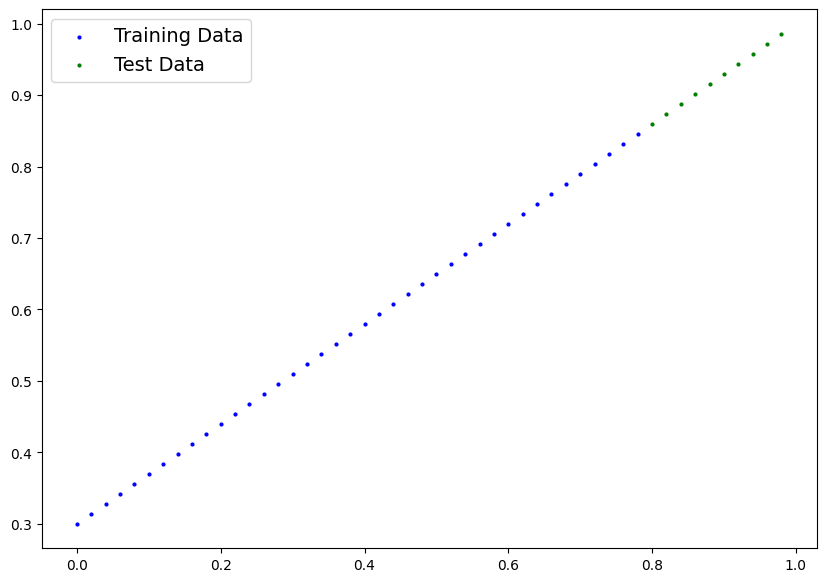

In [56]:
plot_predictions(X_train, y_train, X_test, y_test)

In [57]:
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    # Use nn.Linear() for creating the model parameters
    # Also called linear transform, probing layer, fully-connected layer, ...
    self.linear_layer = nn.Linear(
        in_features=1,
        out_features=1
    )

  def forward(self, x : torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

In [58]:
torch.manual_seed(seed=42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

### Creating Device-Agnostic Code

If a GPU is available, it will be used. Otherwise, a CPU will be used by default.

In [59]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [60]:
#!nvidia-smi #In case you switch to GPU

Let's set the model to use the Target Device

In [61]:
next(model_1.parameters()).device

device(type='cpu')

In [62]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cpu')

### Training

We need
- Loss Function to quantify how good our model is
- An Optimizer to grow closer to a good model approximation (given our measure)
- A Training Loop
- A Testing Loop

In [63]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(
    params=model_1.parameters(),
    lr=0.01
)

In [64]:
torch.manual_seed(42)

ecount = []
loss_records = []
test_loss_records = []

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

epochs = 200
for epoch in range(epochs):
  model_1.train()

  y_preds = model_1.forward(X_train)

  loss = loss_fn(y_preds, y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  if epoch % 10 == 0:
    model_1.eval()
    with torch.inference_mode():
      y_test_preds = model_1.forward(X_test)
      test_loss = loss_fn(y_test_preds, y_test)
      print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")
    ecount.append(epoch)
    loss_records.append(loss.item())
    test_loss_records.append(test_loss.item())

Epoch: 0 | Loss: 0.5551779866218567 | Test Loss: 0.5739762187004089
Epoch: 10 | Loss: 0.4399680495262146 | Test Loss: 0.4392663538455963
Epoch: 20 | Loss: 0.3247582018375397 | Test Loss: 0.30455657839775085
Epoch: 30 | Loss: 0.20954827964305878 | Test Loss: 0.16984674334526062
Epoch: 40 | Loss: 0.09433844685554504 | Test Loss: 0.03513689711689949
Epoch: 50 | Loss: 0.023886386305093765 | Test Loss: 0.04784906655550003
Epoch: 60 | Loss: 0.0199567973613739 | Test Loss: 0.04580312222242355
Epoch: 70 | Loss: 0.016517987474799156 | Test Loss: 0.0375305712223053
Epoch: 80 | Loss: 0.013089170679450035 | Test Loss: 0.029944902285933495
Epoch: 90 | Loss: 0.009653178043663502 | Test Loss: 0.02167237363755703
Epoch: 100 | Loss: 0.006215679459273815 | Test Loss: 0.014086711220443249
Epoch: 110 | Loss: 0.002787243574857712 | Test Loss: 0.005814164876937866
Epoch: 120 | Loss: 0.0012645035749301314 | Test Loss: 0.013801807537674904
Epoch: 130 | Loss: 0.0012645035749301314 | Test Loss: 0.01380180753767

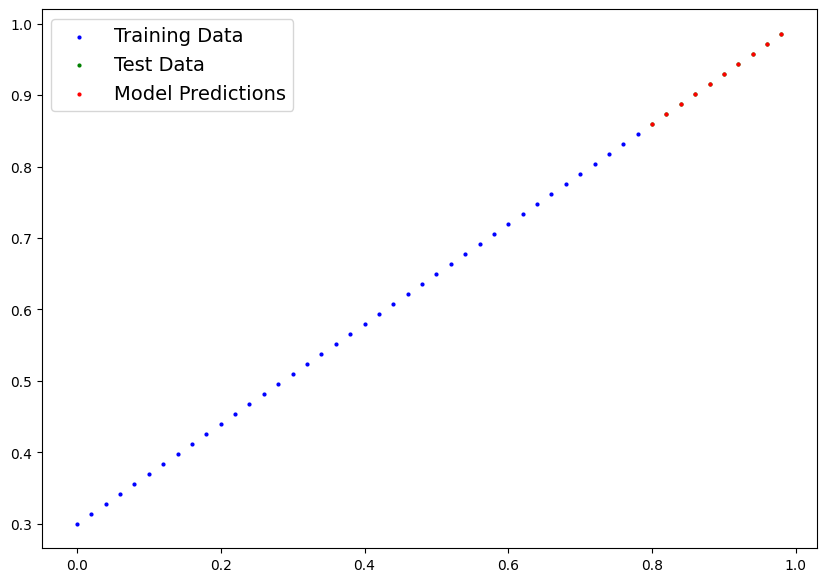

In [65]:
with torch.inference_mode():
  y_test_preds = model_1.forward(X_test.cpu())
plot_predictions(predictions=y_test_preds)

In [66]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

### Saving the model (again)

In [67]:
from pathlib import Path

MODELS_PATH = Path("models")
MODELS_FILE_NAME = "01_workflow_video_2.pth"

MODELS_SAVEPATH = MODELS_PATH / MODELS_FILE_NAME

In [68]:
torch.save(obj=model_1.state_dict(), f=MODELS_SAVEPATH)

### Loading the model (again)

In [69]:
loaded_model_1 = LinearRegressionModelV2()

loaded_model_1.load_state_dict(state_dict=torch.load(f=MODELS_SAVEPATH, weights_only=True))

loaded_model_1.state_dict(), model_1.state_dict()

(OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
              ('linear_layer.bias', tensor([0.3025]))]),
 OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
              ('linear_layer.bias', tensor([0.3025]))]))

As a last exercise, I wanted to recreate the plot function.

In [71]:
def plot_data(
    X_train,
    y_train,
    X_test,
    y_test,
    predictions=None
):
  plt.scatter(X_train, y_train,
              c="b", s=4,
              label = "Training Data"
              )
  plt.scatter(X_test, y_test,
              c="g", s=4,
              label="Test Data"
              )
  if predictions is not None:
    plt.scatter(X_test, predictions,
                c="r", s=4,
                label="Predictions")
  plt.title("Linear Regression Model")
  plt.plot()

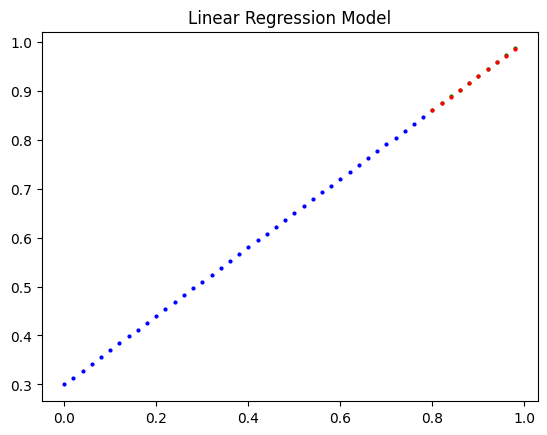

In [73]:
with torch.inference_mode():
  y_test_preds = model_1.forward(X_test)
plot_data(X_train, y_train, X_test, y_test, y_test_preds)